## Import library

In [1]:
import os
import argparse

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable

from models.resnet import ResNet50

## FLOPs & Paremeters & Architecture

In [2]:
!pip install thop
!pip install torchsummary

In [3]:
from thop import profile
from torchsummary import summary

model = ResNet50(num_classes=10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
model = model.to(device)

dummy_input = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy_input, ))

print(f"FLOPs: {flops}")
print(f"Params: {params}")
summary(model, input_size=(3, 32, 32))

Device: cuda
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 328947712.0
Params: 23513162.0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]          

## 設定超參數(請填空 λ)

In [4]:
SPARSITY_REGULARIZATION = True
#### 設定λ(balance factor) ####
################################################
#          請填空          #
################################################
LAMBDA = 1e-4


SEED = 1
TRAIN_BATCH_SIZE = 100
TEST_BATCH_SIZE = 1000

EPOCHS = 40
LEARNING_RATE = 1e-3

LOG_INTERVAL = 100
CUDA = True

RESUME = False
START_EPOCH = 0

WEIGHT_PATH = './models/model_best.pth'

In [5]:
if(torch.cuda.is_available()):
    CUDA = True
    kwargs = {'num_workers': 1, 'pin_memory': True}
    torch.cuda.manual_seed(SEED)
else:
    CUDA = False
    kwargs = {}


##下載資料集


這裡將訓練集做Augmentation(Pad, RandCrop, Random)，測試集不用做Augmentation

In [6]:
#### 資料集 ####
train_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.Pad(4),
                       transforms.RandomCrop(32),
                       transforms.RandomHorizontalFlip(),
                       transforms.ToTensor(),
                       transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                   ])),
    batch_size=TRAIN_BATCH_SIZE, shuffle=True, **kwargs)
test_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data', train=False, transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                   ])),
    batch_size=TEST_BATCH_SIZE, shuffle=True, **kwargs)

## 定義模型與設定Optimizer & CrossEntropy Loss


In [7]:
model = ResNet50(num_classes=10)
if CUDA:
    model.cuda()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

##使用論文中稀疏化的方式更新參數(請填空)

In [8]:
def updateBN():
  for m in model.modules():
      if isinstance(m, nn.BatchNorm2d):
          m.weight.grad.data.add_(LAMBDA * torch.sign(m.weight.data))


## 定義訓練跟測試函數
需自行撰寫儲存每個epoch之train acc與test acc的code，以便後續繪製train acc與test acc結果圖!

In [9]:
train_acc_epoch = []
test_acc_epoch = []

def train(epoch):
    model.train()
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        if CUDA:
            data, target = data.cuda(), target.cuda()
        data, target = Variable(data), Variable(target)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()

        if SPARSITY_REGULARIZATION:
            updateBN()
        optimizer.step()

        pred = output.data.max(1, keepdim=True)[1]
        correct += pred.eq(target.data.view_as(pred)).cpu().sum().item()  # <-- 確保是數值
        total   += target.size(0)

        if batch_idx % LOG_INTERVAL == 0:
            print('Train Epoch: {} [{}/{} ({:.1f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.data.item()))

    acc = 100.0 * correct / total
    train_acc_epoch.append(acc)
    print(f'Train Epoch: {epoch} Accuracy: {correct}/{total} ({acc:.2f}%)')


def test():
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            if CUDA:
                data, target = data.cuda(), target.cuda()
            data, target = Variable(data), Variable(target)

            output = model(data)
            loss = criterion(output, target)
            test_loss += loss.item() * data.size(0)

            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).cpu().sum().item()  # <-- .item()
            total   += target.size(0)

    test_loss /= len(test_loader.dataset)
    acc = 100.0 * correct / total
    test_acc_epoch.append(acc)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset), acc))

    return correct / float(total)  # 回傳 0~1 的正確率（非百分比）


##########################################################################################

best_prec1 = 0.0  # 與 test() 的回傳同尺度（0~1）
for epoch in range(START_EPOCH, EPOCHS):
    # 在 0.5*EPOCHS 與 0.75*EPOCHS 時將 LR 調為 1/10
    if epoch in {int(EPOCHS * 0.5), int(EPOCHS * 0.75)}:
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.1

    train(epoch)
    prec1 = test()  # 0~1

    # 儲存最佳權重
    if prec1 > best_prec1:
        best_prec1 = prec1  # 先更新
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'best_prec1': best_prec1,
            'optimizer': optimizer.state_dict(),
        }, WEIGHT_PATH)

print('\nTRAIN PRUNED MODEL DONE!')


Train Epoch: 0 [0/50000 (0.0%)]	Loss: 2.502492
Train Epoch: 0 [10000/50000 (20.0%)]	Loss: 1.993330
Train Epoch: 0 [20000/50000 (40.0%)]	Loss: 1.812962
Train Epoch: 0 [30000/50000 (60.0%)]	Loss: 1.670610
Train Epoch: 0 [40000/50000 (80.0%)]	Loss: 1.568652
Train Epoch: 0 Accuracy: 15780/50000 (31.56%)

Test set: Average loss: 2.3790, Accuracy: 4028/10000 (40.28%)

Train Epoch: 1 [0/50000 (0.0%)]	Loss: 1.709814
Train Epoch: 1 [10000/50000 (20.0%)]	Loss: 1.558490
Train Epoch: 1 [20000/50000 (40.0%)]	Loss: 1.379713
Train Epoch: 1 [30000/50000 (60.0%)]	Loss: 1.217865
Train Epoch: 1 [40000/50000 (80.0%)]	Loss: 1.285675
Train Epoch: 1 Accuracy: 25012/50000 (50.02%)

Test set: Average loss: 1.2329, Accuracy: 5550/10000 (55.50%)

Train Epoch: 2 [0/50000 (0.0%)]	Loss: 1.280307
Train Epoch: 2 [10000/50000 (20.0%)]	Loss: 1.069687
Train Epoch: 2 [20000/50000 (40.0%)]	Loss: 1.075814
Train Epoch: 2 [30000/50000 (60.0%)]	Loss: 1.134596
Train Epoch: 2 [40000/50000 (80.0%)]	Loss: 1.044117
Train Epoch: 2 

##繪製Sparsity-Training結果圖

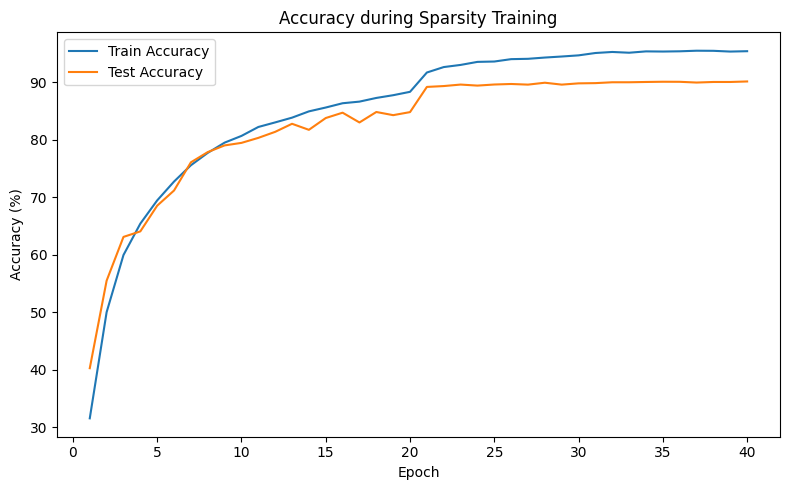

In [12]:

import matplotlib.pyplot as plt

epochs = list(range(1, len(train_acc_epoch)+1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc_epoch, label='Train Accuracy')
plt.plot(epochs, test_acc_epoch, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy during Sparsity Training')
plt.legend()
plt.tight_layout()
plt.show()

## 繪製scaling factor 分布圖

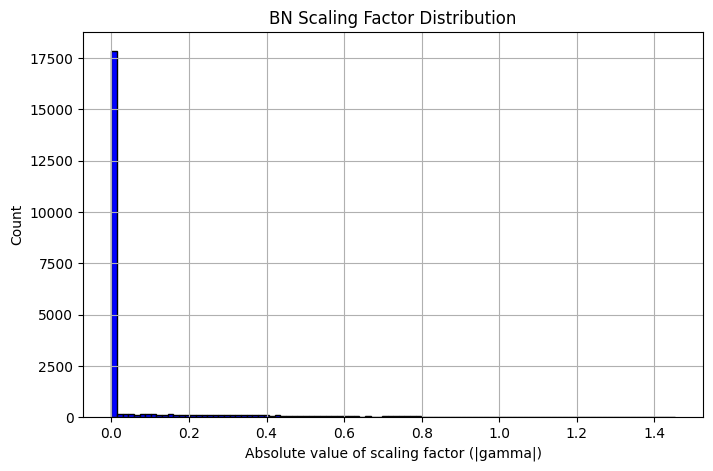

In [11]:
#繪製 scaling factor 分布圖

import torch
import matplotlib.pyplot as plt

def plot_bn_scaling_distribution(model, title='BN Scaling Factor Distribution'):
    bn_weights = []

    for m in model.modules():
        if isinstance(m, torch.nn.BatchNorm2d):
            # 取出 gamma（即 weight）
            bn_weights.append(m.weight.data.abs().clone().cpu())

    if not bn_weights:
        print("No BatchNorm2d layers found.")
        return

    all_bn = torch.cat(bn_weights)

    plt.figure(figsize=(8, 5))
    plt.hist(all_bn.numpy(), bins=100, color='blue', edgecolor='black')
    plt.xlabel('Absolute value of scaling factor (|gamma|)')
    plt.ylabel('Count')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_bn_scaling_distribution(model)